## Artificial Neural Network

### Calibration

In [4]:
import numpy as np

In [5]:
# Clicked at: (210, 370)
# Clicked at: (236, 259)
# Clicked at: (265, 317)
# Clicked at: (269, 210)
# Clicked at: (312, 339)
# Clicked at: (328, 258)
# Clicked at: (341, 270)
# Clicked at: (392, 313)
# Clicked at: (382, 206)
# Clicked at: (430, 329)
# Clicked at: (418, 257)
camera_pixel_coords = np.array([
    [251,  54],
    [358,  68],
    [298,  99],
    [417,  99],
    [275, 142],
    [358, 158],
    [343, 169],
    [297, 214],
    [417, 216],
    [282, 247],
    [357, 247]
], dtype=np.float32)

robot_coordinates = np.array([[393.6,-47.6], [245.8,-29.9], [325.3,11.4], [164.9,7.9], [356.9,73.4],
                              [244.5,92.9], [262.6,107.8], [323.9,170.4], [164.6,168.5], [343.1,215.1], [243.9,212.2]], dtype=np.float32)


In [ ]:
def least_squares(camera_pixel_coords, robot_coordinates):
    
    A_x = np.vstack([camera_pixel_coords[:, 0], np.ones(len(camera_pixel_coords))]).T
    b_x = robot_coordinates[:, 0]
    slope_x, intercept_x = np.linalg.pinv(A_x) @ b_x

    A_y = np.vstack([camera_pixel_coords[:, 1], np.ones(len(camera_pixel_coords))]).T
    b_y = robot_coordinates[:, 1]
    slope_y, intercept_y = np.linalg.pinv(A_y) @ b_y

    return slope_x, intercept_x, slope_y, intercept_y

slope_x, intercept_x, slope_y, intercept_y = least_squares(camera_pixel_coords, robot_coordinates)

print(f"Slope X: {slope_x}, Intercept X: {intercept_x}")
print(f"Slope Y: {slope_y}, Intercept Y: {intercept_y}")

Slope X: -1.354535422349058, Intercept X: 728.8379898805302
Slope Y: 1.3615780318983308, Intercept Y: -122.75301490625793


In [13]:
predicted_robot_coordinates = np.zeros_like(camera_pixel_coords)
for i in range(len(camera_pixel_coords)):
    predicted_robot_coordinates[i, 0] = slope_x * camera_pixel_coords[i, 0] + intercept_x
    predicted_robot_coordinates[i, 1] = slope_y * camera_pixel_coords[i, 1] + intercept_y
print("Predicted robot coordinates:\n", predicted_robot_coordinates)

mean_squared_error = np.mean((predicted_robot_coordinates - robot_coordinates) ** 2)
print("Mean Squared Error:", mean_squared_error)

Predicted robot coordinates:
 [[388.8496   -49.227802]
 [243.9143   -30.165709]
 [325.18643   12.04321 ]
 [163.99672   12.04321 ]
 [356.34076   70.591064]
 [243.9143    92.37631 ]
 [264.23233  107.353676]
 [326.54095  168.62468 ]
 [163.99672  171.34784 ]
 [346.859    213.55676 ]
 [245.26884  213.55676 ]]
Mean Squared Error: 4.4437203


## Training deep neural network

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)


camera_mean = camera_pixel_coords.mean(axis=0)
camera_std = camera_pixel_coords.std(axis=0)
robot_mean = robot_coordinates.mean(axis=0)
robot_std = robot_coordinates.std(axis=0)

X = (camera_pixel_coords - camera_mean) / camera_std
Y = (robot_coordinates - robot_mean) / robot_std

X_tensor = torch.tensor(X)
Y_tensor = torch.tensor(Y)

class CoordNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

model = CoordNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = criterion(output, Y_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

torch.save({
    'model_state_dict': model.state_dict(),
    'camera_mean': camera_mean,
    'camera_std': camera_std,
    'robot_mean': robot_mean,
    'robot_std': robot_std
}, 'camera_to_robot_model.pt')

print("\n Model saved as 'camera_to_robot_model.pt'.")

Epoch 0 | Loss: 0.9926
Epoch 20 | Loss: 0.0250
Epoch 40 | Loss: 0.0007
Epoch 60 | Loss: 0.0006
Epoch 80 | Loss: 0.0002

 Model saved as 'camera_to_robot_model.pt'.


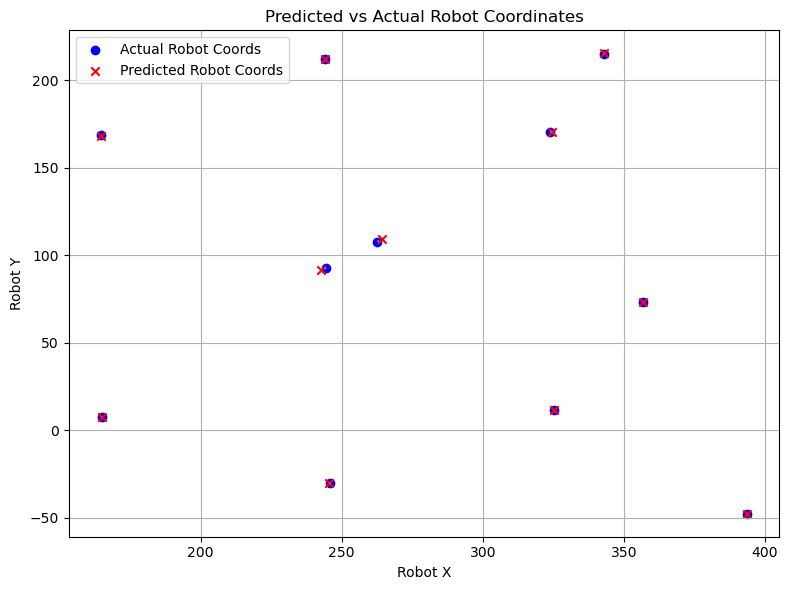

In [ ]:
with torch.no_grad():
    predictions = model(X_tensor).numpy()
    predictions_denorm = predictions * robot_std + robot_mean

plt.figure(figsize=(8, 6))
plt.scatter(robot_coordinates[:, 0], robot_coordinates[:, 1], label='Actual Robot Coords', color='blue')
plt.scatter(predictions_denorm[:, 0], predictions_denorm[:, 1], label='Predicted Robot Coords', color='red', marker='x')
for i in range(len(robot_coordinates)):
    plt.plot([robot_coordinates[i, 0], predictions_denorm[i, 0]],
             [robot_coordinates[i, 1], predictions_denorm[i, 1]], 'gray', linestyle='dotted')
plt.title("Predicted vs Actual Robot Coordinates")
plt.xlabel("Robot X")
plt.ylabel("Robot Y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Predict sub-routine

In [5]:
def predict_robot_coords(camera_x, camera_y):
    checkpoint = torch.load('camera_to_robot_model.pt', weights_only=False)
    
    model = CoordNet()
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    cam_mean = checkpoint['camera_mean']
    cam_std = checkpoint['camera_std']
    rob_mean = checkpoint['robot_mean']
    rob_std = checkpoint['robot_std']
    
    input_tensor = torch.tensor([(camera_x - cam_mean[0]) / cam_std[0],
                                 (camera_y - cam_mean[1]) / cam_std[1]]).float().unsqueeze(0)
    
    with torch.no_grad():
        pred_norm = model(input_tensor)
        pred_actual = pred_norm * torch.tensor(rob_std) + torch.tensor(rob_mean)
        return pred_actual.numpy().flatten()

## Bring to home

In [6]:
import cv2
import numpy as np
from xarm.wrapper import XArmAPI


arm = XArmAPI('192.168.1.155')
arm.motion_enable(enable=True)
arm.set_mode(0)
arm.set_state(0)
arm.connect()
arm.move_gohome()

SDK_VERSION: 1.14.8
ROBOT_IP: 192.168.1.155, VERSION: v2.2.0, PROTOCOL: V1, DETAIL: 6,9,LI1006,DL1000,v2.2.0, TYPE1300: [0, 0]
change protocol identifier to 3
ControllerError, code: 2
[motion_enable], xArm is not ready to move
[set_state], xArm is ready to move


0

ControllerError had clean
ControllerError, code: 21
ControllerError had clean
ControllerError, code: 22
ControllerError, code: 2
servo_error_code, servo_id=1, status=3, code=0
servo_error_code, servo_id=2, status=3, code=0
servo_error_code, servo_id=3, status=3, code=0
servo_error_code, servo_id=4, status=3, code=0
servo_error_code, servo_id=5, status=3, code=0
servo_error_code, servo_id=6, status=3, code=0
ControllerError had clean
servo_error_code, servo_id=1, status=0, code=0
servo_error_code, servo_id=2, status=0, code=0
servo_error_code, servo_id=3, status=0, code=0
servo_error_code, servo_id=4, status=0, code=0
servo_error_code, servo_id=5, status=0, code=0
servo_error_code, servo_id=6, status=0, code=0
ControllerError, code: 22
ControllerError had clean
ControllerError, code: 31
ControllerError, code: 2
ControllerError had clean
ControllerError, code: 2
servo_error_code, servo_id=1, status=3, code=0
servo_error_code, servo_id=2, status=3, code=0
servo_error_code, servo_id=3, sta

## Box coordinates

In [7]:
# Clicked at: (250, 349)
box = predict_robot_coords(251,  54)
box_x, box_y = box

## Pick up sub-routine

In [8]:
import time
def pick_up_and_drop(x_robot, y_robot):
    arm.set_position(x_robot, y_robot, 70, speed=100)  
    arm.set_position(x_robot, y_robot, 18, speed=100, wait=True)  
    arm.set_suction_cup(False)
    time.sleep(1)
    # arm.set_position(x_robot, y_robot, 16.5, wait=True)  
    arm.set_position(x_robot, y_robot, 70, speed=100, wait=True)  
    arm.set_position(box_x, box_y, 200, speed=100)
    arm.set_position(box_x, box_y, 100, speed=100)
    arm.set_suction_cup(True)
    arm.set_position(box_x, box_y, 200, speed=100)

## Capture image

In [9]:
import cv2

cap = cv2.VideoCapture(1)

while True:
    ret, frame = cap.read()

    if not ret:
        print("Can't receive frame. Exiting...")
        break

    cv2.imshow('Webcam Preview - Press Q to capture', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        cv2.imwrite('captured_image.jpg', frame)
        print("Image saved as captured_image.jpg")
        break

cap.release()
cv2.destroyAllWindows()

Image saved as captured_image.jpg


## Vision API

In [10]:
import dotenv
import os
from google import genai
from google.genai import types
from PIL import Image
import io
import os
import requests
from io import BytesIO

dotenv.load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

model_name = "gemini-2.0-flash" 

bounding_box_system_instructions = """
    Return bounding boxes as a JSON array with labels. Never return masks or code fencing. Limit to 25 objects.
    If an object is present multiple times, name them according to their unique characteristic (colors, size, position, unique characteristics, etc..).
    """

client = genai.Client(api_key=GEMINI_API_KEY)

safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT",
        threshold="BLOCK_ONLY_HIGH",
    ),
]

## Plot sub-routine

In [11]:
import json
import random
import io
from PIL import Image, ImageDraw, ImageFont
from PIL import ImageColor

additional_colors = [colorname for (colorname, colorcode) in ImageColor.colormap.items()]

def plot_bounding_boxes(im, bounding_boxes):
    """
    Plots bounding boxes on an image with markers for each a name, using PIL, normalized coordinates, and different colors.

    Args:
        img_path: The path to the image file.
        bounding_boxes: A list of bounding boxes containing the name of the object
         and their positions in normalized [y1 x1 y2 x2] format.
    """

    # Load the image
    img = im
    width, height = img.size
    print(img.size)
    # Create a drawing object
    draw = ImageDraw.Draw(img)

    # Define a list of colors
    colors = [
    'red',
    'green',
    'blue',
    'yellow',
    'orange',
    'pink',
    'purple',
    'brown',
    'gray',
    'beige',
    'turquoise',
    'cyan',
    'magenta',
    'lime',
    'navy',
    'maroon',
    'teal',
    'olive',
    'coral',
    'lavender',
    'violet',
    'gold',
    'silver',
    ] + additional_colors

    # Parsing out the markdown fencing
    bounding_boxes = parse_json(bounding_boxes)

    font = ImageFont.load_default()

    # Iterate over the bounding boxes
    for i, bounding_box in enumerate(json.loads(bounding_boxes)):
      # Select a color from the list
      color = colors[i % len(colors)]

      # Convert normalized coordinates to absolute coordinates
      abs_y1 = int(bounding_box["box_2d"][0]/1000 * height)
      abs_x1 = int(bounding_box["box_2d"][1]/1000 * width)
      abs_y2 = int(bounding_box["box_2d"][2]/1000 * height)
      abs_x2 = int(bounding_box["box_2d"][3]/1000 * width)

      if abs_x1 > abs_x2:
        abs_x1, abs_x2 = abs_x2, abs_x1

      if abs_y1 > abs_y2:
        abs_y1, abs_y2 = abs_y2, abs_y1

      # Draw the bounding box
      draw.rectangle(
          ((abs_x1, abs_y1), (abs_x2, abs_y2)), outline=color, width=4
      )

      # Draw the text
      if "label" in bounding_box:
        draw.text((abs_x1 + 8, abs_y1 + 6), bounding_box["label"], fill=color, font=font)

    # Display the image
    img.save("output_image.jpg")  # or "output_image.png"
    print("Image saved as output_image.jpg")

    img.show()

In [ ]:
def parse_json(json_output):
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line == "```json":
            json_output = "\n".join(lines[i+1:])  
            json_output = json_output.split("```")[0]  
            break  
    return json_output

In [ ]:
prompt = "Detect the 2d bounding boxes of the small cubes (with “label” as color of the small cube) outside the brown box"  # @param {type:"string"}

image = "captured_image.jpg"

im = Image.open(io.BytesIO(open(image, "rb").read()))

im.thumbnail([1024,1024], Image.Resampling.LANCZOS)

response = client.models.generate_content(
    model=model_name,
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        system_instruction=bounding_box_system_instructions,
        temperature=0.5,
    )
)

print(response.text)

```json
[
  {"box_2d": [185, 509, 236, 543], "label": "green"},
  {"box_2d": [179, 468, 236, 509], "label": "yellow"}
]
```


In [14]:
plot_bounding_boxes(im, response.text)

(640, 480)
Image saved as output_image.jpg


## Pick up routine

In [ ]:
import torch
bounding_boxes = parse_json(response.text)
with open("bounding_box.json", "w") as f:
    f.write(bounding_boxes)
    
for i, bounding_box in enumerate(json.loads(bounding_boxes)):

    width, height = im.size
    
    # Convert normalized coordinates to absolute coordinates
    abs_y1 = int(bounding_box["box_2d"][0]/1000 * height)
    abs_x1 = int(bounding_box["box_2d"][1]/1000 * width)
    abs_y2 = int(bounding_box["box_2d"][2]/1000 * height)
    abs_x2 = int(bounding_box["box_2d"][3]/1000 * width)

    if abs_x1 > abs_x2:
        abs_x1, abs_x2 = abs_x2, abs_x1

    if abs_y1 > abs_y2:
        abs_y1, abs_y2 = abs_y2, abs_y
    
    centroid1 = (abs_x1 + abs_x2) / 2
    centroid2 = (abs_y1 + abs_y2) / 2

    c1_robot, c2_robot = predict_robot_coords(centroid1, centroid2)
    pick_up_and_drop(c1_robot, c2_robot)
arm.move_gohome()

0